<a href="https://colab.research.google.com/github/FatherNurt/FUNt-Cosmologiical-Model-of-All-Things/blob/main/FPDP_Engine_Solar_Weather_Adapter_v1_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FPDP Engine — Solar Weather Adapter v1.1
## Canonical Refactor of FUNt Space Weather hHRT Operator v1.1

**Flow • Potential Difference • Persistence**

Historical / descriptive analysis only. **No prediction performed.**

This notebook preserves the operational behavior of:

```text
FUNt_Space_Weather_hHRT_Operator_v1.1_Geometry_Lag_Edition
```

It refactors the notebook into the canonical FPDP architecture without intentionally changing the validated science.

---

## Canonical dependency graph

```text
FUNt
   ↓ defines
FPDP Mathematics
   ↓ implemented by
FPDP Engine
   ↓ executes
FPDP History Analysis
   ↓ generates
History Plot Against h³π and Ψ
   ↓ supported by
Solar Weather Adapter
   ↓ produces
Standard Outputs
```

## Machine-readable architecture

```yaml
Theory:
  name: FUNt
  relationship: defines

Mathematics:
  name: FPDP Mathematics
  definition: Flow • Potential Difference • Persistence
  relationship: implemented by

Engine:
  name: FPDP Engine
  relationship: executes

Primary Analysis:
  name: FPDP History Analysis
  visualization: History Plot Against h³π and Ψ

Adapter:
  name: Solar Weather Adapter
  role: translate NOAA/SWPC, GOES, geometry, and lag inputs into canonical FPDP quantities

Outputs:
  - SITREP
  - History Plot
  - Audit
```

## Beginner Note

If you can raise children, run a household, operate a car, troubleshoot burnt toast, wire a barn, repair a pump, or rebuild a carburetor, you can learn this notebook.

The software isn't smarter than you—it simply speaks a different language.

Like any language, it becomes familiar one step at a time.

You do not need to become a programmer to use this engine. You only need curiosity, patience, and a willingness to learn.


## Continuity / Migration Note

This is an architectural refactor, not a mathematical rewrite.

Preserved from the v1.1 Geometry and Lag Edition:

1. Physical geometry scaffold: subsolar point, dipole tilt approximation, GOES local time, and GSE/GSM placeholders.
2. DSCOVR / OMNI L1 solar-wind lag correction.
3. Current-state estimation separated from one-window aftershock / relaxation watch.
4. Configuration hashing and run audit.
5. Storm/no-storm classification scaffolding.
6. Event notebook exporter for quiet intervals, false alarms, storm transitions, suppressed transitions, and aftershock relaxation.

**Research rule:** this notebook must not be tuned to a single event.

## v1.1 Compatibility Cleanup

This version keeps old column/function names where needed for saved logs, but exposes canonical FPDP aliases for new work.

Canonical names now emphasized:

```text
compute_fpdp_history_analysis
fpdp_estimated_kp
fpdp_state
fpdp_error_est_minus_actual
```

Legacy names retained for backward compatibility:

```text
compute_funt_ledger
funt_estimated_kp
funt_state
kp_error_est_minus_actual
```

Reason: saved v1.0/v1.1 logs and prior Colab runs should remain readable while new notebooks use FPDP language.


## Notebook Philosophy

Every run should answer five reader questions:

1. **What happened?** Estimate vs actual Kp.
2. **Why did it happen?** Flow, potential difference, persistence, relaxation, h³π gate, and geometry coupling.
3. **How did the model decide?** Ledger columns, SITREP, and audit box.
4. **What should be watched next?** Aftershock / relaxation state only.
5. **What is Nature teaching?** Persistent systems correct most disturbances before transition.

The Solar Weather Adapter translates domain-specific observations into the FPDP language. The FPDP Engine processes the canonical quantities.

In [1]:
# ============================================================
# FPDP Engine — Solar Weather Adapter v1.1
# ============================================================

import json
import math
import os
from dataclasses import dataclass, asdict
from datetime import datetime, timezone
from pathlib import Path
from typing import Optional, Dict, Any, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 220)

VERSION = "fpdp-solar-weather-adapter-v1.1-compatibility-cleanup"
ORIGINAL_IMPLEMENTATION = "FUNt Space Weather hHRT Operator v1.1 Geometry and Lag Edition"
UTC_NOW = datetime.now(timezone.utc)

print("FPDP Engine — Solar Weather Adapter", VERSION)
print("Original implementation:", ORIGINAL_IMPLEMENTATION)
print("Run UTC:", UTC_NOW.isoformat())


FPDP Engine — Solar Weather Adapter fpdp-solar-weather-adapter-v1.1-compatibility-cleanup
Original implementation: FUNt Space Weather hHRT Operator v1.1 Geometry and Lag Edition
Run UTC: 2026-06-27T18:59:36.473596+00:00


## Boundary Conditions

These are not decoration. They prevent the notebook from becoming a curve-fitting toy.

### 1. Causality boundary
Use only data available at analysis time. Observed Kp is used for validation, not to construct the estimate.

### 2. FPDP transition boundary
A regime transition is logged only when the confirmed h³π gate is true.

```text
T > |Ψ|
E >= h³π
τ >= τ_HRT
signal survives x consecutive windows
G >= G_min
```

### 3. Persistence survival boundary
One spike is not enough. A candidate transition must survive `survival_windows_x` consecutive windows before it is confirmed.

### 4. Geometry boundary
The same solar input does not couple to Earth identically at every time. The Solar Weather Adapter computes `G_geometry`, and the FPDP Engine requires `G >= G_min` before storm-regime transition is allowed.

### 5. No-transition cap
If the confirmed h³π gate is false, the final Kp estimate is capped.

### 6. Raw-pressure boundary
Raw transition pressure is retained for diagnosis. It may spike. The final estimate may not follow it unless boundary gates confirm transition.

### 7. Relaxation boundary
If transport is not reinforced, accumulated persistence must decay.

### 8. Humility boundary
If Nature disagrees with the model, the model is revised, not Nature.

In [2]:
# --------------------- CONFIG ---------------------

CONFIG = {
    "version": VERSION,
    "original_implementation": ORIGINAL_IMPLEMENTATION,
    "theory": "FUNt",
    "mathematics": "FPDP Mathematics",
    "mathematics_definition": "Flow • Potential Difference • Persistence",
    "engine": "FPDP Engine",
    "adapter": "Solar Weather Adapter",
    "primary_analysis": "FPDP History Analysis",
    "visualization": "History Plot Against h³π and Ψ",

    # FPDP constants / thresholds
    "h3pi": 3.0 * math.pi,           # transition-energy gate
    "tau_HRT": 3,                    # consecutive transport windows required
    "survival_windows_x": 3,         # signal must survive x consecutive full-candidate windows
    "gate_confirm_windows": 3,       # kept for backward compatibility; mirrors survival_windows_x
    "psi_floor": 1.4656,             # user anchor; used as persistence reference

    # Solar Weather Adapter geometry gate. This is a physical scaffold, not final geospace physics.
    "geometry_gate_min": 0.62,
    "geometry_floor": 0.40,          # never let geometry erase physical pressure completely
    "geometry_utc_weight": 0.45,
    "geometry_season_weight": 0.35,
    "geometry_dipole_weight": 0.20,

    # Model response behavior
    "kp_base": 1.0,
    "kp_cap_no_transition": 3.0,
    "quiet_gain": 0.35,
    "storm_gain": 1.20,
    "relaxation_rate": 0.18,
    "persistence_gain": 0.42,

    # Classification thresholds
    "perturbation_threshold": 0.20,
    "transport_threshold": 0.30,
    "high_pressure_threshold": 0.70,
    "aftershock_watch_threshold": 0.55,
    "raw_pressure_audit_threshold": 3.0,
    "needle_multiplier": 2.0,        # flags sharp one-sample raw pressure jumps

    # Data handling
    "local_data_dir": "fpdp_solar_weather_data",
    "prediction_log_csv": "fpdp_solar_weather_adapter_v11_run_log.csv",

    # v1.1 geometry and lag upgrades
    "use_real_geometry_scaffold": True,
    "use_l1_lag_correction": True,
    "default_l1_lag_minutes": 45,
    "lag_speed_reference_km_s": 400.0,
    "l1_distance_km": 1_500_000.0,
    "goes_longitude_deg": -75.2,     # GOES-East approximate longitude; edit if using GOES-West.
    "storm_threshold_kp": 5.0,
    "quiet_threshold_kp": 3.0,
    "event_export_dir": "fpdp_solar_weather_event_notebooks_v11",

    # NOAA/SWPC JSON endpoints. These may change; see NOAA SWPC service notices.
    "endpoints": {
        "kp_observed_3h": "https://services.swpc.noaa.gov/products/noaa-planetary-k-index.json",
        "kp_estimated_1m": "https://services.swpc.noaa.gov/products/noaa-estimated-planetary-k-index-1-minute.json",
        "goes_magnetometer_1m": "https://services.swpc.noaa.gov/json/goes/primary/magnetometers-1-day.json",
        "goes_electron_flux_5m": "https://services.swpc.noaa.gov/json/goes/primary/integral-electrons-1-day.json",
        "solar_wind_mag_1h": "https://services.swpc.noaa.gov/products/solar-wind/mag-1-hour.json",
        "solar_wind_plasma_1h": "https://services.swpc.noaa.gov/products/solar-wind/plasma-1-hour.json",
    }
}

Path(CONFIG["local_data_dir"]).mkdir(exist_ok=True)
print(json.dumps({k:v for k,v in CONFIG.items() if k != "endpoints"}, indent=2))


{
  "version": "fpdp-solar-weather-adapter-v1.1-compatibility-cleanup",
  "original_implementation": "FUNt Space Weather hHRT Operator v1.1 Geometry and Lag Edition",
  "theory": "FUNt",
  "mathematics": "FPDP Mathematics",
  "mathematics_definition": "Flow \u2022 Potential Difference \u2022 Persistence",
  "engine": "FPDP Engine",
  "adapter": "Solar Weather Adapter",
  "primary_analysis": "FPDP History Analysis",
  "visualization": "History Plot Against h\u00b3\u03c0 and \u03a8",
  "h3pi": 9.42477796076938,
  "tau_HRT": 3,
  "survival_windows_x": 3,
  "gate_confirm_windows": 3,
  "psi_floor": 1.4656,
  "geometry_gate_min": 0.62,
  "geometry_floor": 0.4,
  "geometry_utc_weight": 0.45,
  "geometry_season_weight": 0.35,
  "geometry_dipole_weight": 0.2,
  "kp_base": 1.0,
  "kp_cap_no_transition": 3.0,
  "quiet_gain": 0.35,
  "storm_gain": 1.2,
  "relaxation_rate": 0.18,
  "persistence_gain": 0.42,
  "perturbation_threshold": 0.2,
  "transport_threshold": 0.3,
  "high_pressure_threshold":

## Solar Weather Adapter: Data Loading

The notebook tries live NOAA/SWPC feeds first. If a feed fails, it prints the failure and continues with whatever data is available. This lets the notebook run in restricted environments and still preserve the audit structure.

In [3]:
import urllib.request
import urllib.error


def fetch_json(url: str, timeout: int = 6) -> Any:
    """Fetch JSON from URL. Returns Python object or raises exception."""
    req = urllib.request.Request(url, headers={"User-Agent": "FUNt-hHRT-Operator/1.1"})
    with urllib.request.urlopen(req, timeout=timeout) as r:
        return json.loads(r.read().decode("utf-8"))


def safe_fetch(name: str, url: str) -> Optional[Any]:
    try:
        data = fetch_json(url)
        out = Path(CONFIG["local_data_dir"]) / f"{name}_{UTC_NOW.strftime('%Y%m%dT%H%M%SZ')}.json"
        out.write_text(json.dumps(data)[:20_000_000])
        print(f"OK: {name} rows/items saved -> {out}")
        return data
    except Exception as e:
        print(f"FAILED: {name}: {type(e).__name__}: {e}")
        return None

raw = {name: safe_fetch(name, url) for name, url in CONFIG["endpoints"].items()}


OK: kp_observed_3h rows/items saved -> fpdp_solar_weather_data/kp_observed_3h_20260627T185936Z.json
FAILED: kp_estimated_1m: HTTPError: HTTP Error 404: Not Found
OK: goes_magnetometer_1m rows/items saved -> fpdp_solar_weather_data/goes_magnetometer_1m_20260627T185936Z.json
OK: goes_electron_flux_5m rows/items saved -> fpdp_solar_weather_data/goes_electron_flux_5m_20260627T185936Z.json
FAILED: solar_wind_mag_1h: HTTPError: HTTP Error 404: Not Found
FAILED: solar_wind_plasma_1h: HTTPError: HTTP Error 404: Not Found


In [4]:
# --------------------- PARSERS ---------------------


def parse_time_series_json(data, time_cols=("time_tag", "time", "timestamp", "DateTime")) -> pd.DataFrame:
    """Parse common SWPC JSON structures into a DataFrame with UTC datetime index."""
    if data is None:
        return pd.DataFrame()

    # Some SWPC product feeds are list-of-lists with header row.
    if isinstance(data, list) and len(data) > 0 and isinstance(data[0], list):
        header = data[0]
        rows = data[1:]
        df = pd.DataFrame(rows, columns=header)
    elif isinstance(data, list) and (len(data) == 0 or isinstance(data[0], dict)):
        df = pd.DataFrame(data)
    elif isinstance(data, dict):
        # Try common payload keys.
        for key in ("data", "observations", "products"):
            if key in data and isinstance(data[key], list):
                return parse_time_series_json(data[key], time_cols=time_cols)
        df = pd.DataFrame([data])
    else:
        return pd.DataFrame()

    if df.empty:
        return df

    time_col = None
    for c in time_cols:
        if c in df.columns:
            time_col = c
            break
    if time_col is None:
        # Fall back to first column if it looks time-like.
        time_col = df.columns[0]

    df[time_col] = pd.to_datetime(df[time_col], errors="coerce", utc=True)
    df = df.dropna(subset=[time_col]).sort_values(time_col).set_index(time_col)

    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="ignore")
    return df


def numeric_columns(df: pd.DataFrame) -> List[str]:
    return [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]

frames = {name: parse_time_series_json(data) for name, data in raw.items()}
for name, df in frames.items():
    print("\n", name, df.shape)
    if not df.empty:
        display(df.tail(3))



 kp_observed_3h (62, 3)


/tmp/ipykernel_5621/976565981.py:41: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors="ignore")
/tmp/ipykernel_5621/976565981.py:41: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors="ignore")
/tmp/ipykernel_5621/976565981.py:41: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors="ignore")


,Kp,a_running,station_count
time_tag,,,
2026-06-27 09:00:00+00:00,1.33,5,8
2026-06-27 12:00:00+00:00,1.67,6,8
2026-06-27 15:00:00+00:00,1.33,5,8



 kp_estimated_1m (0, 0)

 goes_magnetometer_1m (1438, 6)


,satellite,He,Hp,Hn,total,arcjet_flag
time_tag,,,,,,
2026-06-27 18:55:00+00:00,18,14.997412,105.675835,18.690096,108.358833,False
2026-06-27 18:56:00+00:00,18,14.886211,105.800514,18.602045,108.449982,False
2026-06-27 18:57:00+00:00,18,14.756143,105.944138,18.548248,108.563110,False



 goes_electron_flux_5m (287, 3)


,satellite,flux,energy
time_tag,,,
2026-06-27 18:40:00+00:00,19,3039.825684,>=2 MeV
2026-06-27 18:45:00+00:00,19,2807.125000,>=2 MeV
2026-06-27 18:50:00+00:00,19,2834.550537,>=2 MeV



 solar_wind_mag_1h (0, 0)

 solar_wind_plasma_1h (0, 0)


## Solar Weather Adapter: Geometry, Lag, and Hash Utilities

These additions are intentionally transparent. The geometry terms are physical approximations, not final geospace physics. They replace the earlier timestamp-only proxy with explicit terms that can be audited and improved.

In [5]:
# --------------------- v1.1 GEOMETRY, LAG, AND HASH UTILITIES ---------------------

import hashlib
from datetime import timedelta

def stable_json(obj):
    """Stable JSON for hashing configuration dictionaries."""
    return json.dumps(obj, sort_keys=True, default=str, separators=(",", ":"))

def config_hash(cfg: Dict[str, Any]) -> str:
    """Short SHA256 hash of the full configuration dictionary."""
    return hashlib.sha256(stable_json(cfg).encode("utf-8")).hexdigest()[:16]

CONFIG["config_hash"] = config_hash(CONFIG)
Path(CONFIG.get("event_export_dir", "funt_space_weather_event_notebooks_v11")).mkdir(exist_ok=True)
print("CONFIG HASH:", CONFIG["config_hash"])

def solar_declination_deg(index: pd.DatetimeIndex) -> np.ndarray:
    """Approximate solar declination / subsolar latitude in degrees."""
    idx = pd.DatetimeIndex(index)
    idx = idx.tz_localize("UTC") if idx.tz is None else idx.tz_convert("UTC")
    doy = idx.dayofyear + (idx.hour + idx.minute/60 + idx.second/3600)/24.0
    return 23.44 * np.sin(2*np.pi*(doy - 81.0)/365.25)

def subsolar_longitude_deg(index: pd.DatetimeIndex) -> np.ndarray:
    """Approximate subsolar longitude in degrees east."""
    idx = pd.DatetimeIndex(index)
    idx = idx.tz_localize("UTC") if idx.tz is None else idx.tz_convert("UTC")
    hour = idx.hour + idx.minute/60 + idx.second/3600
    lon = 180.0 - 15.0 * hour
    return ((lon + 180) % 360) - 180

def approximate_dipole_tilt_deg(index: pd.DatetimeIndex) -> np.ndarray:
    """First-pass dipole tilt approximation; replace with IGRF/GSM later."""
    idx = pd.DatetimeIndex(index)
    idx = idx.tz_localize("UTC") if idx.tz is None else idx.tz_convert("UTC")
    hour = idx.hour + idx.minute/60 + idx.second/3600
    decl = solar_declination_deg(idx)
    diurnal = 6.5 * np.cos(2*np.pi*(hour - 3.0)/24.0)
    return decl + diurnal

def goes_local_time_hours(index: pd.DatetimeIndex, goes_longitude_deg: float = -75.2) -> np.ndarray:
    """Approximate GOES local solar time from UTC and spacecraft longitude."""
    idx = pd.DatetimeIndex(index)
    idx = idx.tz_localize("UTC") if idx.tz is None else idx.tz_convert("UTC")
    hour = idx.hour + idx.minute/60 + idx.second/3600
    return (hour + goes_longitude_deg/15.0) % 24.0

def estimate_l1_lag_minutes(speed_km_s: Optional[float], cfg: Dict[str, Any]) -> float:
    """Estimate L1-to-Earth propagation lag."""
    if speed_km_s is None or not np.isfinite(speed_km_s) or speed_km_s <= 0:
        return float(cfg.get("default_l1_lag_minutes", 45))
    lag_min = float(cfg.get("l1_distance_km", 1_500_000.0)) / float(speed_km_s) / 60.0
    return float(np.clip(lag_min, 20, 90))

def apply_l1_lag_to_solar_wind_features(df: pd.DataFrame, cfg: Dict[str, Any]) -> pd.DataFrame:
    """Shift L1 solar-wind-derived features forward to estimated Earth-arrival time."""
    out = df.copy()
    sw_cols = [c for c in out.columns if c.startswith("bz_") or c.startswith("solar_wind_")]
    if not sw_cols:
        out["l1_lag_minutes_used"] = np.nan
        return out
    lag_min = float(cfg.get("default_l1_lag_minutes", 45))
    shifted = out[sw_cols].copy()
    shifted.index = shifted.index + pd.to_timedelta(lag_min, unit="m")
    shifted = shifted.reindex(out.index, method="nearest", tolerance=pd.Timedelta("10min"))
    for c in sw_cols:
        out[c + "_raw_l1"] = out[c]
        out[c + "_l1lag"] = shifted[c]
        out[c] = out[c + "_l1lag"].fillna(out[c])
    out["l1_lag_minutes_used"] = lag_min
    return out

def real_geometry_scaffold(index: pd.DatetimeIndex, cfg: Dict[str, Any]) -> pd.DataFrame:
    """v1.1 physical geometry scaffold."""
    idx = pd.DatetimeIndex(index)
    idx = idx.tz_localize("UTC") if idx.tz is None else idx.tz_convert("UTC")
    sub_lat = solar_declination_deg(idx)
    sub_lon = subsolar_longitude_deg(idx)
    dipole_tilt = approximate_dipole_tilt_deg(idx)
    goes_lt = goes_local_time_hours(idx, cfg.get("goes_longitude_deg", -75.2))

    subsolar_factor = 1.0 - np.clip(np.abs(sub_lat) / 23.44, 0, 1) * 0.35
    tilt_factor = 0.5 + 0.5 * np.cos(np.deg2rad(dipole_tilt - 10.0))
    lt_phase = 0.5 + 0.5 * np.cos(2*np.pi*(goes_lt - 12.0)/24.0)
    rotation_factor = 0.5 + 0.5 * np.cos(np.deg2rad(sub_lon))

    G_raw = 0.30*subsolar_factor + 0.30*tilt_factor + 0.25*lt_phase + 0.15*rotation_factor
    floor = cfg.get("geometry_floor", 0.40)
    G = floor + (1-floor)*np.clip(G_raw, 0, 1)

    return pd.DataFrame({
        "subsolar_lat_deg": sub_lat,
        "subsolar_lon_deg": sub_lon,
        "dipole_tilt_deg_approx": dipole_tilt,
        "goes_local_time_hr": goes_lt,
        "geometry_subsolar_factor": subsolar_factor,
        "geometry_dipole_tilt_factor": tilt_factor,
        "geometry_goes_local_time_factor": lt_phase,
        "geometry_rotation_factor": rotation_factor,
        "G_geometry_v11": np.clip(G, 0, 1),
        "GSE_x_placeholder": np.nan,
        "GSM_z_placeholder": np.nan,
    }, index=index)


CONFIG HASH: c294dab5a607f16e


## Solar Weather Adapter: Feature Construction

The adapter builds normalized signals from available feeds and translates them toward canonical FPDP quantities: flow, potential difference, persistence inputs, and geometry coupling.

In [6]:
# --------------------- FEATURE HELPERS ---------------------


def robust_z(series: pd.Series, window: int = 180, min_periods: int = 20) -> pd.Series:
    """Rolling robust z-score using median and MAD. Causal because it only uses prior/current window."""
    s = pd.to_numeric(series, errors="coerce")
    med = s.rolling(window, min_periods=min_periods).median()
    mad = (s - med).abs().rolling(window, min_periods=min_periods).median()
    return ((s - med) / (1.4826 * mad.replace(0, np.nan))).replace([np.inf, -np.inf], np.nan).fillna(0)


def unit_clip(x, scale=4.0):
    return np.clip(np.abs(x) / scale, 0, 1)


def build_feature_frame(frames: Dict[str, pd.DataFrame]) -> pd.DataFrame:
    # Establish a common time axis from the densest available feed.
    candidates = [(name, df) for name, df in frames.items() if not df.empty]
    if not candidates:
        return pd.DataFrame()
    base_name, base = max(candidates, key=lambda x: len(x[1]))
    idx = base.index.sort_values().unique()
    out = pd.DataFrame(index=idx)

    # GOES magnetometer feature
    mag = frames.get("goes_magnetometer_1m", pd.DataFrame())
    if not mag.empty:
        cols = numeric_columns(mag)
        # Prefer Hp or total field columns if present; otherwise first numeric column.
        pref = [c for c in cols if c.lower() in ("hp", "he", "hn", "total", "bt") or "hp" in c.lower()]
        col = pref[0] if pref else (cols[0] if cols else None)
        if col:
            m = pd.to_numeric(mag[col], errors="coerce")
            mag_disturb = robust_z(m.diff().abs().rolling(5, min_periods=1).mean(), window=240)
            out["magnetic_perturbation"] = unit_clip(mag_disturb).reindex(out.index, method="nearest", tolerance=pd.Timedelta("3min"))

    # Electron flux feature
    ele = frames.get("goes_electron_flux_5m", pd.DataFrame())
    if not ele.empty:
        cols = numeric_columns(ele)
        pref = [c for c in cols if "flux" in c.lower()]
        col = pref[0] if pref else (cols[0] if cols else None)
        if col:
            e = pd.to_numeric(ele[col], errors="coerce")
            loge = np.log10(e.clip(lower=1e-12))
            # Both sudden drop and sudden rise can signal reconfiguration; use absolute log change.
            ele_disturb = robust_z(loge.diff().abs().rolling(3, min_periods=1).mean(), window=120)
            out["electron_disturbance"] = unit_clip(ele_disturb).reindex(out.index, method="nearest", tolerance=pd.Timedelta("8min"))

    # Solar wind magnetic Bz feature
    swmag = frames.get("solar_wind_mag_1h", pd.DataFrame())
    if not swmag.empty:
        cols = numeric_columns(swmag)
        bz_col = next((c for c in cols if c.lower() == "bz_gsm" or "bz" in c.lower()), None)
        if bz_col:
            bz = pd.to_numeric(swmag[bz_col], errors="coerce")
            southward = (-bz).clip(lower=0)
            bz_stress = (southward / 10.0).clip(0, 1)
            out["bz_southward_stress"] = bz_stress.reindex(out.index, method="nearest", tolerance=pd.Timedelta("8min"))

    # Solar wind plasma feature
    plasma = frames.get("solar_wind_plasma_1h", pd.DataFrame())
    if not plasma.empty:
        cols = numeric_columns(plasma)
        speed_col = next((c for c in cols if "speed" in c.lower()), None)
        dens_col = next((c for c in cols if "density" in c.lower() or c.lower() == "density"), None)
        if speed_col:
            v = pd.to_numeric(plasma[speed_col], errors="coerce")
            v_stress = ((v - 350.0) / 350.0).clip(lower=0, upper=1)
            out["solar_wind_speed_stress"] = v_stress.reindex(out.index, method="nearest", tolerance=pd.Timedelta("8min"))
        if dens_col:
            n = pd.to_numeric(plasma[dens_col], errors="coerce")
            n_stress = (np.log1p(n) / np.log1p(50)).clip(0, 1)
            out["solar_wind_density_stress"] = n_stress.reindex(out.index, method="nearest", tolerance=pd.Timedelta("8min"))

    # Observed Kp for validation only.
    kp = frames.get("kp_observed_3h", pd.DataFrame())
    if not kp.empty:
        cols = numeric_columns(kp)
        kp_col = next((c for c in cols if "kp" in c.lower() or "k" == c.lower()), None)
        if kp_col is None and cols:
            kp_col = cols[-1]
        if kp_col:
            out["observed_kp_validation_only"] = pd.to_numeric(kp[kp_col], errors="coerce").reindex(out.index, method="ffill")

    out = out.sort_index()
    feature_cols = [c for c in out.columns if c != "observed_kp_validation_only"]
    out[feature_cols] = out[feature_cols].fillna(0)

    # v1.1: apply explicit L1 lag correction to solar-wind-derived features.
    if CONFIG.get("use_l1_lag_correction", True):
        out = apply_l1_lag_to_solar_wind_features(out, CONFIG)
    return out

features = build_feature_frame(frames)
print(features.shape)
display(features.tail(10))


(1438, 4)


,magnetic_perturbation,electron_disturbance,observed_kp_validation_only,l1_lag_minutes_used
time_tag,,,,
2026-06-27 18:48:00+00:00,0.579106,0.018496,1.33,NaN
2026-06-27 18:49:00+00:00,0.618494,0.018496,1.33,NaN
2026-06-27 18:50:00+00:00,0.397298,0.018496,1.33,NaN
2026-06-27 18:51:00+00:00,0.001664,0.018496,1.33,NaN
2026-06-27 18:52:00+00:00,0.068462,0.018496,1.33,NaN
2026-06-27 18:53:00+00:00,0.007364,0.018496,1.33,NaN
2026-06-27 18:54:00+00:00,0.020302,0.018496,1.33,NaN
2026-06-27 18:55:00+00:00,0.203835,0.018496,1.33,NaN
2026-06-27 18:56:00+00:00,0.127663,0.018496,1.33,NaN


In [7]:
# If live data is unavailable, create a small synthetic example so readers can inspect the model mechanics.
# Synthetic mode is clearly labeled and should never be used as validation.

if features.empty or len(features) < 10:
    print("Live data unavailable or insufficient. Using synthetic demonstration data only.")
    idx = pd.date_range(end=UTC_NOW, periods=120, freq="5min")
    x = np.linspace(0, 1, len(idx))
    features = pd.DataFrame(index=idx)
    features["magnetic_perturbation"] = 0.08 + 0.65*np.exp(-((x-0.55)/0.10)**2)
    features["electron_disturbance"] = 0.05 + 0.45*np.exp(-((x-0.50)/0.08)**2)
    features["bz_southward_stress"] = 0.15*np.exp(-((x-0.52)/0.11)**2)
    features["solar_wind_speed_stress"] = 0.10*np.exp(-((x-0.60)/0.20)**2)
    features["observed_kp_validation_only"] = 1.7 + 0.5*np.exp(-((x-0.62)/0.14)**2)
    features.attrs["synthetic"] = True
else:
    features.attrs["synthetic"] = False

print("Synthetic demonstration mode:", features.attrs.get("synthetic", False))


Synthetic demonstration mode: False


## FPDP History Analysis

This section preserves the v1.1 hHRT ledger core while exposing canonical FPDP columns.

```text
Flow                 -> transport response / movement of disturbance
Potential Difference -> perturbation or imbalance entering the system
Persistence          -> accumulated strain after relaxation leakage
Geometry G           -> adapter-computed coupling allowance
h³π gate             -> descriptive transition gate
```

In [8]:
# --------------------- FPDP HISTORY ANALYSIS (legacy hHRT ledger core preserved) ---------------------


def consecutive_true_count(s: pd.Series) -> pd.Series:
    """Causal consecutive TRUE counter."""
    b = s.fillna(False).astype(bool)
    return b.astype(int).groupby((~b).cumsum()).cumsum()


def earth_geometry_proxy(index: pd.DatetimeIndex, cfg: Dict[str, Any]) -> pd.DataFrame:
    """
    First-pass causal Earth-geometry coupling proxy.

    Uses timestamp-only terms so it cannot leak future Kp:
    - UTC/local-time phase proxy: Earth rotates under the solar wind/magnetosphere.
    - Seasonal tilt proxy: axial tilt changes magnetospheric coupling geometry through the year.
    - Dipole wobble proxy: simple diurnal harmonic placeholder for geomagnetic orientation.

    This is intentionally transparent and replaceable. Later versions can replace this with
    real dipole tilt, subsolar point, GSM coordinates, GOES local time, and solar-wind lag.
    """
    idx = pd.DatetimeIndex(index).tz_convert("UTC") if pd.DatetimeIndex(index).tz is not None else pd.DatetimeIndex(index).tz_localize("UTC")
    hour = idx.hour + idx.minute / 60.0 + idx.second / 3600.0
    doy = idx.dayofyear + hour / 24.0

    # UTC phase: broad 24-hour coupling harmonic, normalized to [0, 1].
    # The phase offset is deliberately configurable in future versions; 09 UTC is a neutral first-pass anchor.
    utc_phase = 0.5 + 0.5 * np.cos(2.0 * np.pi * (hour - 9.0) / 24.0)

    # Seasonal tilt: absolute seasonal exposure proxy, normalized [0, 1].
    season_phase = 0.5 + 0.5 * np.sin(2.0 * np.pi * (doy - 80.0) / 365.25)

    # Dipole wobble placeholder: 12-hour harmonic, normalized [0, 1].
    dipole_phase = 0.5 + 0.5 * np.cos(2.0 * np.pi * (hour - 3.0) / 12.0)

    G_raw = (
        cfg["geometry_utc_weight"] * utc_phase
        + cfg["geometry_season_weight"] * season_phase
        + cfg["geometry_dipole_weight"] * dipole_phase
    )
    G = cfg["geometry_floor"] + (1.0 - cfg["geometry_floor"]) * G_raw

    return pd.DataFrame({
        "geometry_utc_phase": utc_phase,
        "geometry_season_phase": season_phase,
        "geometry_dipole_phase": dipole_phase,
        "G_geometry": np.clip(G, 0, 1),
    }, index=index)


def compute_funt_ledger(features: pd.DataFrame, cfg: Dict[str, Any]) -> pd.DataFrame:
    df = features.copy()
    feature_cols = [c for c in df.columns if c != "observed_kp_validation_only"]

    # Weighted perturbation index. Keep transparent and editable.
    weights = {
        "magnetic_perturbation": 0.35,
        "electron_disturbance": 0.25,
        "bz_southward_stress": 0.25,
        "solar_wind_speed_stress": 0.10,
        "solar_wind_density_stress": 0.05,
    }
    total_weight = sum(weights.get(c, 0) for c in feature_cols) or 1.0
    df["perturbation_index"] = sum(df[c].fillna(0) * weights.get(c, 0) for c in feature_cols) / total_weight
    df["perturbation_index"] = df["perturbation_index"].clip(0, 1)

    # Transport: nonlinear but bounded response to perturbation.
    df["transport_T"] = np.sqrt(df["perturbation_index"].clip(0, 1))

    # Earth geometry gate.
    # v1.1 uses physical geometry scaffold when enabled, while preserving v0.7.2 proxy fields for audit.
    geom_proxy = earth_geometry_proxy(df.index, cfg)
    for c in geom_proxy.columns:
        df[c] = geom_proxy[c]

    if cfg.get("use_real_geometry_scaffold", True):
        geom_real = real_geometry_scaffold(df.index, cfg)
        for c in geom_real.columns:
            df[c] = geom_real[c]
        df["G_geometry_proxy_v072"] = df["G_geometry"]
        df["G_geometry"] = df["G_geometry_v11"]

    df["condition_geometry_ge_min"] = df["G_geometry"] >= cfg["geometry_gate_min"]

    # Persistence accumulator with relaxation leakage.
    psi_vals = []
    tau_vals = []
    psi = 0.0
    tau = 0
    for T in df["transport_T"].fillna(0).values:
        gain = cfg["persistence_gain"] * max(0.0, T - cfg["transport_threshold"])
        leak = cfg["relaxation_rate"] * psi
        psi = max(0.0, psi + gain - leak)
        if T > cfg["transport_threshold"]:
            tau += 1
        else:
            tau = 0
        psi_vals.append(psi)
        tau_vals.append(tau)

    df["Psi_persistence"] = psi_vals
    df["tau_persistent_windows"] = tau_vals

    # Causal energy pressure. Geometry modulates coupling but does not erase raw internal pressure.
    psi_fraction = df["Psi_persistence"] / (cfg["psi_floor"] + df["Psi_persistence"])
    pressure_fraction_raw = (0.65 * df["transport_T"] + 0.35 * psi_fraction).clip(0, 1.5)
    pressure_fraction_coupled = (pressure_fraction_raw * df["G_geometry"]).clip(0, 1.5)
    df["E_transition_pressure_raw"] = cfg["h3pi"] * pressure_fraction_raw
    df["E_transition_pressure"] = cfg["h3pi"] * pressure_fraction_coupled

    # Boundary conditions.
    df["condition_T_gt_absPsi"] = df["transport_T"] > psi_fraction
    df["condition_E_ge_h3pi"] = df["E_transition_pressure"] >= cfg["h3pi"]
    df["condition_tau_ge_HRT"] = df["tau_persistent_windows"] >= cfg["tau_HRT"]

    # Candidate = physical pressure wants transition. Confirmed = candidate survives x windows and geometry admits coupling.
    df["h3pi_candidate"] = df["condition_T_gt_absPsi"] & df["condition_E_ge_h3pi"] & df["condition_tau_ge_HRT"]
    df["candidate_survival_count"] = consecutive_true_count(df["h3pi_candidate"])
    df["condition_survives_x"] = df["candidate_survival_count"] >= int(cfg["survival_windows_x"])

    df["h3pi_gate_raw"] = df["h3pi_candidate"]
    df["h3pi_gate_confirm_count"] = df["candidate_survival_count"]
    df["h3pi_gate"] = df["h3pi_candidate"] & df["condition_survives_x"] & df["condition_geometry_ge_min"]

    # Raw pressure is intentionally retained. It is the model's internal transition pressure before discipline.
    raw_quiet = cfg["kp_base"] + cfg["quiet_gain"] * 6.0 * df["transport_T"] + 0.35 * df["Psi_persistence"]
    raw_storm = cfg["kp_base"] + cfg["storm_gain"] * 5.0 * df["transport_T"] + 0.55 * df["Psi_persistence"]
    df["raw_transition_pressure_kp"] = np.where(df["h3pi_candidate"], raw_storm, raw_quiet).clip(0, 9)

    # Final estimate is what the model is allowed to publish after boundary conditions.
    df["funt_estimated_kp"] = np.where(
        df["h3pi_gate"],
        raw_storm,
        np.minimum(raw_quiet, cfg["kp_cap_no_transition"])
    )
    df["funt_estimated_kp"] = df["funt_estimated_kp"].clip(0, 9)

    # Audit flags.
    df["no_transition_cap_active"] = (~df["h3pi_gate"]) & (df["raw_transition_pressure_kp"] > cfg["kp_cap_no_transition"])
    df["geometry_suppression_audit"] = df["h3pi_candidate"] & df["condition_survives_x"] & (~df["condition_geometry_ge_min"])
    df["persistence_suppression_audit"] = df["h3pi_candidate"] & (~df["condition_survives_x"])
    raw_diff = df["raw_transition_pressure_kp"].diff().abs().fillna(0)
    local_median = raw_diff.rolling(30, min_periods=5).median().replace(0, np.nan)
    df["needle_spike_audit"] = (raw_diff > (cfg["needle_multiplier"] * local_median.fillna(raw_diff.median() or 1))) & (df["raw_transition_pressure_kp"] > cfg["raw_pressure_audit_threshold"])

    # Human-readable state.
    def classify(row):
        if row["h3pi_gate"]:
            return "h3pi transition confirmed"
        if row["geometry_suppression_audit"]:
            return "candidate survived / geometry suppressed"
        if row["persistence_suppression_audit"]:
            return "candidate impulse / failed survival x"
        if row["no_transition_cap_active"]:
            return "capped pressure / no transition"
        if row["Psi_persistence"] > cfg["high_pressure_threshold"]:
            return "persistent strain"
        if row["transport_T"] > cfg["transport_threshold"]:
            return "transport / perturbed"
        return "quiet / reference"

    df["funt_state"] = df.apply(classify, axis=1)

    # v1.1: separate current-state estimation from one-window aftershock / relaxation watch.
    df["current_transition_state"] = df["funt_state"]
    df["confirmed_transition_recent"] = df["h3pi_gate"].shift(1).rolling(1, min_periods=1).max().fillna(False).astype(bool)
    df["aftershock_watch_1window"] = df["confirmed_transition_recent"] | (df["Psi_persistence"].shift(1).fillna(0) >= cfg["aftershock_watch_threshold"])
    df["aftershock_watch"] = df["aftershock_watch_1window"]

    if "observed_kp_validation_only" in df.columns:
        df["kp_error_est_minus_actual"] = df["funt_estimated_kp"] - df["observed_kp_validation_only"]
        df["abs_error"] = df["kp_error_est_minus_actual"].abs()
    return df

# Canonical public alias. Legacy function/column names are preserved for backward compatibility.
compute_fpdp_history_analysis = compute_funt_ledger

ledger = compute_fpdp_history_analysis(features, CONFIG)

# Canonical FPDP columns exposed for downstream adapters/engine continuity.
ledger["flow"] = ledger["transport_T"]
ledger["potential_difference"] = ledger["perturbation_index"]
ledger["persistence"] = ledger["Psi_persistence"]
ledger["fpdp_pressure"] = ledger["E_transition_pressure"]
ledger["fpdp_estimated_kp"] = ledger["funt_estimated_kp"]
ledger["fpdp_state"] = ledger["funt_state"]
if "kp_error_est_minus_actual" in ledger.columns:
    ledger["fpdp_error_est_minus_actual"] = ledger["kp_error_est_minus_actual"]


display(ledger.tail(12))


,magnetic_perturbation,electron_disturbance,observed_kp_validation_only,l1_lag_minutes_used,perturbation_index,transport_T,geometry_utc_phase,geometry_season_phase,geometry_dipole_phase,G_geometry,subsolar_lat_deg,subsolar_lon_deg,dipole_tilt_deg_approx,goes_local_time_hr,geometry_subsolar_factor,geometry_dipole_tilt_factor,geometry_goes_local_time_factor,geometry_rotation_factor,G_geometry_v11,GSE_x_placeholder,GSM_z_placeholder,G_geometry_proxy_v072,condition_geometry_ge_min,Psi_persistence,tau_persistent_windows,E_transition_pressure_raw,E_transition_pressure,condition_T_gt_absPsi,condition_E_ge_h3pi,condition_tau_ge_HRT,h3pi_candidate,candidate_survival_count,condition_survives_x,h3pi_gate_raw,h3pi_gate_confirm_count,h3pi_gate,raw_transition_pressure_kp,funt_estimated_kp,no_transition_cap_active,geometry_suppression_audit,persistence_suppression_audit,needle_spike_audit,funt_state,current_transition_state,confirmed_transition_recent,aftershock_watch_1window,aftershock_watch,kp_error_est_minus_actual,abs_error,flow,potential_difference,persistence,fpdp_pressure,fpdp_estimated_kp,fpdp_state,fpdp_error_est_minus_actual
time_tag,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-06-27 18:46:00+00:00,1.000000,0.059925,1.33,NaN,0.608302,0.779937,0.083057,0.995878,0.304634,0.874366,23.294992,-101.50,19.707401,13.753333,0.652165,0.992841,0.948243,0.400316,0.874366,NaN,NaN,0.668116,True,1.100819,40,6.192883,5.414847,True,False,True,False,0,False,False,0,False,3.023155,3.000000,True,False,False,False,capped pressure / no transition,capped pressure / no transition,False,True,True,1.670000,1.670000,0.779937,0.608302,1.100819,5.414847,3.000000,capped pressure / no transition,1.670000
2026-06-27 18:47:00+00:00,1.000000,0.059925,1.33,NaN,0.608302,0.779937,0.081857,0.995877,0.300625,0.874022,23.294961,-101.75,19.731055,13.770000,0.652166,0.992806,0.947272,0.398179,0.874022,NaN,NaN,0.667311,True,1.104246,41,6.195395,5.414911,True,False,True,False,0,False,False,0,False,3.024354,3.000000,True,False,False,False,capped pressure / no transition,capped pressure / no transition,False,True,True,1.670000,1.670000,0.779937,0.608302,1.104246,5.414911,3.000000,capped pressure / no transition,1.670000
2026-06-27 18:48:00+00:00,0.579106,0.018496,1.33,NaN,0.345518,0.587808,0.080665,0.995877,0.296632,0.873677,23.294930,-102.00,19.754776,13.786667,0.652166,0.992771,0.946293,0.396044,0.873677,NaN,NaN,0.666509,True,1.026361,42,4.959594,4.333081,True,False,True,False,0,False,False,0,False,2.593623,2.593623,False,False,False,False,persistent strain,persistent strain,False,True,True,1.263623,1.263623,0.587808,0.345518,1.026361,4.333081,2.593623,persistent strain,1.263623
2026-06-27 18:49:00+00:00,0.618494,0.018496,1.33,NaN,0.368495,0.607038,0.079480,0.995876,0.292653,0.873330,23.294898,-102.25,19.778564,13.803333,0.652167,0.992736,0.945305,0.393911,0.873330,NaN,NaN,0.665712,True,0.970572,43,5.032969,4.395444,True,False,True,False,0,False,False,0,False,2.614479,2.614479,False,False,False,False,persistent strain,persistent strain,False,True,True,1.284479,1.284479,0.607038,0.368495,0.970572,4.395444,2.614479,persistent strain,1.284479
2026-06-27 18:50:00+00:00,0.397298,0.018496,1.33,NaN,0.239464,0.489350,0.078304,0.995875,0.288691,0.872983,23.294867,-102.50,19.802420,13.820000,0.652167,0.992700,0.944309,0.391780,0.872983,NaN,NaN,0.664919,True,0.875396,44,4.231323,3.693872,True,False,True,False,0,False,False,0,False,2.334024,2.334024,False,False,False,False,persistent strain,persistent strain,False,True,True,1.004024,1.004024,0.489350,0.239464,0.875396,3.693872,2.334024,persistent strain,1.004024
2026-06-27 18:51:00+00:00,0.001664,0.018496,1.33,NaN,0.008677,0.093151,0.077136,0.995874,0.284744,0.872634,23.294836,-102.75,19.826342,13.836667,0.652168,0.992665,0.943304,0.389651,0.872634,NaN,NaN,0.664130,True,0.717825,0,1.655125,1.444318,False,False,False,False,0,False,False,0,False,1.446855,1.446855,False,False,False,False,persistent strain,persistent strain,

## SITREP and Audit Boxes

The SITREP summarizes the latest state. The audit box preserves the reasoning path and boundary checks.

In [9]:
# --------------------- VERDICT + AUDIT BOXES ---------------------


def latest_verdict(ledger: pd.DataFrame, cfg: Dict[str, Any]) -> Dict[str, Any]:
    row = ledger.iloc[-1]
    verdict = {
        "run_utc": UTC_NOW.isoformat(),
        "version": cfg["version"],
        "synthetic_demo_mode": bool(ledger.attrs.get("synthetic", features.attrs.get("synthetic", False))),
        "latest_time_utc": ledger.index[-1].isoformat(),
        "perturbation_detected": bool(row["perturbation_index"] >= cfg["perturbation_threshold"]),
        "transport_response": bool(row["transport_T"] >= cfg["transport_threshold"]),
        "persistence_threshold_met": bool(row["tau_persistent_windows"] >= cfg["tau_HRT"]),
        "survived_x_windows": bool(row["condition_survives_x"]),
        "geometry_gate_open": bool(row["condition_geometry_ge_min"]),
        "G_geometry": round(float(row["G_geometry"]), 3),
        "h3pi_candidate": bool(row["h3pi_candidate"]),
        "h3pi_transition_confirmed": bool(row["h3pi_gate"]),
        "storm_regime": bool(row["h3pi_gate"]),
        "aftershock_watch": bool(row["aftershock_watch"]),
        "state": str(row.get("fpdp_state", row["funt_state"])),
        "raw_transition_pressure_kp": round(float(row["raw_transition_pressure_kp"]), 3),
        "fpdp_estimated_kp_final": round(float(row.get("fpdp_estimated_kp", row["funt_estimated_kp"])), 3),
        "no_transition_cap_active": bool(row["no_transition_cap_active"]),
    }
    if "observed_kp_validation_only" in ledger.columns and not pd.isna(row.get("observed_kp_validation_only", np.nan)):
        verdict["observed_kp_validation_only"] = round(float(row["observed_kp_validation_only"]), 3)
        verdict["estimate_minus_actual"] = round(float(row["kp_error_est_minus_actual"]), 3)
    return verdict


def latest_audit_ledger(ledger: pd.DataFrame, cfg: Dict[str, Any]) -> Dict[str, Any]:
    row = ledger.iloc[-1]
    return {
        "transport_T": round(float(row["transport_T"]), 4),
        "Psi_persistence": round(float(row["Psi_persistence"]), 4),
        "tau_persistent_windows": int(row["tau_persistent_windows"]),
        "candidate_survival_count": int(row["candidate_survival_count"]),
        "survival_windows_x": int(cfg["survival_windows_x"]),
        "G_geometry": round(float(row["G_geometry"]), 4),
        "geometry_gate_min": round(float(cfg["geometry_gate_min"]), 4),
        "E_transition_pressure_raw": round(float(row["E_transition_pressure_raw"]), 4),
        "E_transition_pressure_coupled": round(float(row["E_transition_pressure"]), 4),
        "h3pi_threshold": round(float(cfg["h3pi"]), 4),
        "condition_T_gt_absPsi": bool(row["condition_T_gt_absPsi"]),
        "condition_E_ge_h3pi": bool(row["condition_E_ge_h3pi"]),
        "condition_tau_ge_HRT": bool(row["condition_tau_ge_HRT"]),
        "condition_survives_x": bool(row["condition_survives_x"]),
        "condition_geometry_ge_min": bool(row["condition_geometry_ge_min"]),
        "raw_transition_pressure_kp": round(float(row["raw_transition_pressure_kp"]), 4),
        "final_estimated_kp": round(float(row.get("fpdp_estimated_kp", row["funt_estimated_kp"])), 4),
    }


def boundary_audit(ledger: pd.DataFrame, cfg: Dict[str, Any]) -> Dict[str, str]:
    return {
        "causality": "PASS - observed Kp is validation only" if "observed_kp_validation_only" in ledger.columns else "PASS - no observed Kp column available",
        "future_kp_leakage": "PASS - Kp is not used in compute_funt_ledger inputs except validation columns",
        "raw_pressure_retained": "PASS" if "raw_transition_pressure_kp" in ledger.columns else "FAIL",
        "final_cap_enforced": "PASS" if (ledger.loc[~ledger["h3pi_gate"], "funt_estimated_kp"] <= cfg["kp_cap_no_transition"] + 1e-9).all() else "FAIL",
        "persistence_survival_required": "PASS" if "condition_survives_x" in ledger.columns else "FAIL",
        "geometry_gate_present": "PASS" if "G_geometry" in ledger.columns else "FAIL",
        "spike_audit_present": "PASS" if "needle_spike_audit" in ledger.columns else "FAIL",
    }

verdict = latest_verdict(ledger, CONFIG)
audit = latest_audit_ledger(ledger, CONFIG)
bounds = boundary_audit(ledger, CONFIG)

print("OPERATIONAL VERDICT")
print(json.dumps(verdict, indent=2))
print("\nAUDIT LEDGER")
print(json.dumps(audit, indent=2))
print("\nBOUNDARY AUDIT")
print(json.dumps(bounds, indent=2))


OPERATIONAL VERDICT
{
  "run_utc": "2026-06-27T18:59:36.473596+00:00",
  "version": "fpdp-solar-weather-adapter-v1.1-compatibility-cleanup",
  "synthetic_demo_mode": false,
  "latest_time_utc": "2026-06-27T18:57:00+00:00",
  "perturbation_detected": false,
  "transport_response": false,
  "persistence_threshold_met": false,
  "survived_x_windows": false,
  "geometry_gate_open": true,
  "G_geometry": 0.871,
  "h3pi_candidate": false,
  "h3pi_transition_confirmed": false,
  "storm_regime": false,
  "aftershock_watch": false,
  "state": "quiet / reference",
  "raw_transition_pressure_kp": 1.461,
  "fpdp_estimated_kp_final": 1.461,
  "no_transition_cap_active": false,
  "observed_kp_validation_only": 1.33,
  "estimate_minus_actual": 0.131
}

AUDIT LEDGER
{
  "transport_T": 0.1805,
  "Psi_persistence": 0.234,
  "tau_persistent_windows": 0,
  "candidate_survival_count": 0,
  "survival_windows_x": 3,
  "G_geometry": 0.8705,
  "geometry_gate_min": 0.62,
  "E_transition_pressure_raw": 1.56,
  "

In [10]:
# --------------------- PERFORMANCE METRICS ---------------------


def validation_metrics(ledger: pd.DataFrame) -> Dict[str, float]:
    if "observed_kp_validation_only" not in ledger.columns:
        return {}
    valid = ledger[["funt_estimated_kp", "observed_kp_validation_only"]].dropna()
    if len(valid) < 3:
        return {}
    err = valid["funt_estimated_kp"] - valid["observed_kp_validation_only"]
    corr = valid["funt_estimated_kp"].corr(valid["observed_kp_validation_only"])
    return {
        "n_validation_points": int(len(valid)),
        "mae": float(err.abs().mean()),
        "rmse": float(np.sqrt((err**2).mean())),
        "bias_est_minus_actual": float(err.mean()),
        "correlation": float(corr) if not pd.isna(corr) else np.nan,
        "max_abs_error": float(err.abs().max()),
    }

metrics = validation_metrics(ledger)
print(json.dumps(metrics, indent=2))


{
  "n_validation_points": 1438,
  "mae": 0.5198933281544155,
  "rmse": 0.6951101584625731,
  "bias_est_minus_actual": -0.016670740365394916,
  "correlation": 0.12704112958081493,
  "max_abs_error": 2.0
}


## Classification and Event Export

Classification scaffolding is retained for audit accumulation. Event notebooks remain optional diagnostic exports.

In [11]:
import re
import nbformat
from nbformat import v4 as nbf

# --------------------- v1.1 CLASSIFICATION + EVENT NOTEBOOK EXPORT ---------------------

def classify_storm_binary(kp_value, threshold=5.0):
    if pd.isna(kp_value):
        return np.nan
    return bool(kp_value >= threshold)

def add_classification_columns(ledger: pd.DataFrame, cfg: Dict[str, Any]) -> pd.DataFrame:
    df = ledger.copy()
    storm_threshold = cfg.get("storm_threshold_kp", 5.0)
    estimate_col = "fpdp_estimated_kp" if "fpdp_estimated_kp" in df.columns else "funt_estimated_kp"
    df["predicted_storm_binary"] = df["h3pi_gate"] | (df[estimate_col] >= storm_threshold)
    if "observed_kp_validation_only" in df.columns:
        df["observed_storm_binary"] = df["observed_kp_validation_only"].apply(lambda x: classify_storm_binary(x, storm_threshold))
        df["classification_result"] = np.select(
            [
                (df["predicted_storm_binary"] == True) & (df["observed_storm_binary"] == True),
                (df["predicted_storm_binary"] == True) & (df["observed_storm_binary"] == False),
                (df["predicted_storm_binary"] == False) & (df["observed_storm_binary"] == True),
                (df["predicted_storm_binary"] == False) & (df["observed_storm_binary"] == False),
            ],
            ["true_positive_storm", "false_alarm", "missed_storm", "correct_quiet"],
            default="unknown"
        )
    else:
        df["observed_storm_binary"] = np.nan
        df["classification_result"] = "no_observed_kp"
    return df

ledger = add_classification_columns(ledger, CONFIG)

def confusion_matrix_from_log(log_path: Path, storm_threshold: float = 5.0) -> pd.DataFrame:
    if not log_path.exists():
        return pd.DataFrame()
    log = pd.read_csv(log_path)
    needed = {"h3pi_transition_confirmed", "observed_kp_validation_only"}
    if not needed.issubset(set(log.columns)):
        return pd.DataFrame()
    pred = log["h3pi_transition_confirmed"].astype(bool)
    obs = pd.to_numeric(log["observed_kp_validation_only"], errors="coerce") >= storm_threshold
    return pd.crosstab(obs, pred, rownames=["Observed storm"], colnames=["Predicted storm"], dropna=False)

def export_event_notebook(event_name: str, event_df: pd.DataFrame, cfg: Dict[str, Any]) -> Optional[str]:
    if event_df.empty:
        return None
    safe_name = re.sub(r"[^A-Za-z0-9_\\-]+", "_", event_name)
    out_dir = Path(cfg.get("event_export_dir", "funt_space_weather_event_notebooks_v11"))
    out_dir.mkdir(exist_ok=True)
    out_path = out_dir / f"{safe_name}_{UTC_NOW.strftime('%Y%m%dT%H%M%SZ')}.ipynb"

    evnb = nbf.new_notebook()
    evnb.cells.append(nbf.new_markdown_cell(f"# Event Notebook: {event_name}\n\nGenerated from FPDP Engine — Solar Weather Adapter v1.1.\n\nConfig hash: `{cfg.get('config_hash')}`"))
    evnb.cells.append(nbf.new_markdown_cell("## Event purpose\n\nThis export isolates a quiet interval, false alarm, storm transition, suppressed transition, or aftershock relaxation event for review."))
    evnb.cells.append(nbf.new_code_cell("import pandas as pd\nfrom io import StringIO\n"))
    csv_text = event_df.tail(120).to_csv()
    csv_literal = repr(csv_text)
    evnb.cells.append(nbf.new_code_cell(f"event_csv = {csv_literal}\nevent_df = pd.read_csv(StringIO(event_csv), index_col=0)\ndisplay(event_df.tail(30))"))
    nbformat.write(evnb, out_path)
    return str(out_path)

event_exports = {}
event_buckets = {
    "quiet_interval": ledger[ledger["funt_state"].eq("quiet / reference")],
    "false_alarm": ledger[ledger["classification_result"].eq("false_alarm")],
    "storm_transition": ledger[ledger["classification_result"].eq("true_positive_storm")],
    "suppressed_transition": ledger[ledger["no_transition_cap_active"] | ledger["geometry_suppression_audit"] | ledger["persistence_suppression_audit"]],
    "aftershock_relaxation": ledger[ledger["aftershock_watch_1window"]],
}
for name, df_ev in event_buckets.items():
    path = export_event_notebook(name, df_ev, CONFIG)
    if path:
        event_exports[name] = path

print("Event notebook exports:")
print(json.dumps(event_exports, indent=2))

cm = confusion_matrix_from_log(Path(CONFIG["prediction_log_csv"]), CONFIG.get("storm_threshold_kp", 5.0))
if cm.empty:
    print("Confusion matrix not yet available. Continue accumulating frozen run logs.")
else:
    display(cm)


Event notebook exports:
{
  "quiet_interval": "fpdp_solar_weather_event_notebooks_v11/quiet_interval_20260627T185936Z.ipynb",
  "suppressed_transition": "fpdp_solar_weather_event_notebooks_v11/suppressed_transition_20260627T185936Z.ipynb",
  "aftershock_relaxation": "fpdp_solar_weather_event_notebooks_v11/aftershock_relaxation_20260627T185936Z.ipynb"
}
Confusion matrix not yet available. Continue accumulating frozen run logs.


## Standard Output: Estimate vs Actual

This chart is the attention hook, but not the proof. It compares current estimate behavior against validation Kp when observed Kp is available.

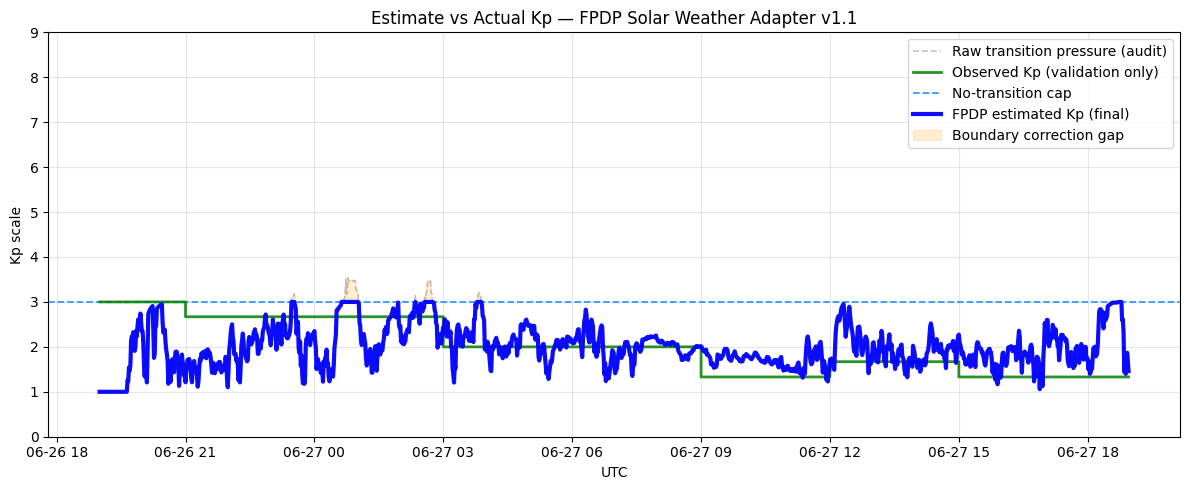

FPDP line visibility audit
Mean final-minus-raw: -0.0089
Max absolute final-minus-raw: 0.5357
Percent nearly overlapping (<0.05 Kp): 97.01 %
Note: if overlap is high, the blue final estimate is still present; it is tracking raw pressure closely except where boundary corrections act.


In [12]:
# --------------------- CHART 1: ESTIMATE VS ACTUAL + RAW PRESSURE ---------------------
estimate_col = "fpdp_estimated_kp" if "fpdp_estimated_kp" in ledger.columns else "funt_estimated_kp"
# Visual audit note:
# The final FPDP estimate is plotted LAST, thick, and above the raw-pressure curve.
# This prevents the gray raw-pressure diagnostic from hiding the blue published estimate.

plt.figure(figsize=(12, 5))

# Raw internal pressure: diagnostic only, intentionally subdued.
plt.plot(
    ledger.index,
    ledger["raw_transition_pressure_kp"],
    linestyle="--",
    linewidth=1.2,
    color="gray",
    alpha=0.45,
    zorder=1,
    label="Raw transition pressure (audit)"
)

# Observed Kp: validation only, drawn as a step curve because official Kp updates discretely.
if "observed_kp_validation_only" in ledger.columns:
    plt.step(
        ledger.index,
        ledger["observed_kp_validation_only"],
        where="post",
        linewidth=2.0,
        color="green",
        alpha=0.85,
        zorder=3,
        label="Observed Kp (validation only)"
    )

# No-transition cap: boundary condition.
plt.axhline(
    CONFIG["kp_cap_no_transition"],
    linestyle="--",
    linewidth=1.3,
    color="dodgerblue",
    alpha=0.90,
    zorder=2,
    label="No-transition cap"
)

# Final FPDP estimate: published estimate after hHRT boundary discipline.
# Drawn last so it remains visible even when raw pressure overlaps it.
plt.plot(
    ledger.index,
    ledger[estimate_col],
    linewidth=3.0,
    color="blue",
    alpha=0.95,
    zorder=6,
    label="FPDP estimated Kp (final)"
)

# Highlight where final estimate differs from raw pressure because a boundary gate/cap acted.
difference = (ledger["raw_transition_pressure_kp"] - ledger[estimate_col]).abs()
if (difference > 0.05).any():
    plt.fill_between(
        ledger.index,
        ledger[estimate_col],
        ledger["raw_transition_pressure_kp"],
        where=(difference > 0.05),
        color="orange",
        alpha=0.18,
        zorder=0,
        label="Boundary correction gap"
    )

plt.ylim(0, 9)
plt.title("Estimate vs Actual Kp — FPDP Solar Weather Adapter v1.1")
plt.ylabel("Kp scale")
plt.xlabel("UTC")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Visibility / overlap audit
if {"funt_estimated_kp", "raw_transition_pressure_kp"}.issubset(ledger.columns):
    diff = ledger[estimate_col] - ledger["raw_transition_pressure_kp"]
    print("FPDP line visibility audit")
    print("Mean final-minus-raw:", round(float(diff.mean()), 4))
    print("Max absolute final-minus-raw:", round(float(diff.abs().max()), 4))
    print("Percent nearly overlapping (<0.05 Kp):", round(float((diff.abs() < 0.05).mean() * 100), 2), "%")
    print("Note: if overlap is high, the blue final estimate is still present; it is tracking raw pressure closely except where boundary corrections act.")


## FPDP History Analysis: Meaning Decoder

This plot shows disturbance, transport, persistence, geometry, and h³π gate behavior in one view.

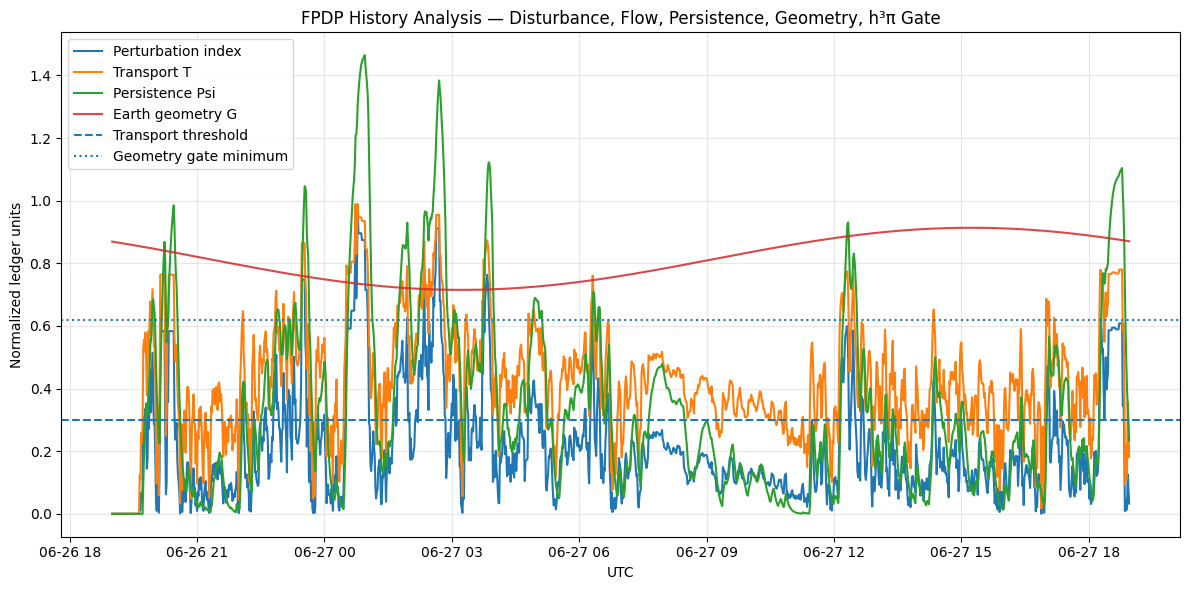

In [13]:
# --------------------- CHART 2: TRANSITION LEDGER ---------------------

plt.figure(figsize=(12, 6))
plt.plot(ledger.index, ledger["perturbation_index"], label="Perturbation index")
plt.plot(ledger.index, ledger["transport_T"], label="Transport T")
plt.plot(ledger.index, ledger["Psi_persistence"], label="Persistence Psi")
plt.plot(ledger.index, ledger["G_geometry"], label="Earth geometry G", alpha=0.85)
plt.axhline(CONFIG["transport_threshold"], linestyle="--", label="Transport threshold")
plt.axhline(CONFIG["geometry_gate_min"], linestyle=":", label="Geometry gate minimum")

# Mark candidate and confirmed h3pi openings separately.
if ledger["h3pi_candidate"].any():
    cand_times = ledger.index[ledger["h3pi_candidate"]]
    plt.scatter(cand_times, ledger.loc[cand_times, "transport_T"], marker="o", s=35, label="h3pi candidate")
if ledger["h3pi_gate"].any():
    gate_times = ledger.index[ledger["h3pi_gate"]]
    plt.scatter(gate_times, ledger.loc[gate_times, "transport_T"], marker="x", s=70, label="h3pi confirmed")

plt.title("FPDP History Analysis — Disturbance, Flow, Persistence, Geometry, h³π Gate")
plt.ylabel("Normalized ledger units")
plt.xlabel("UTC")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## History Plot Against h³π and Ψ — Energy Pressure

This audit plot separates raw internal pressure from geometry-coupled pressure. A raw pressure spike may be real as an impulse, but final transition requires coupled pressure plus survival x.

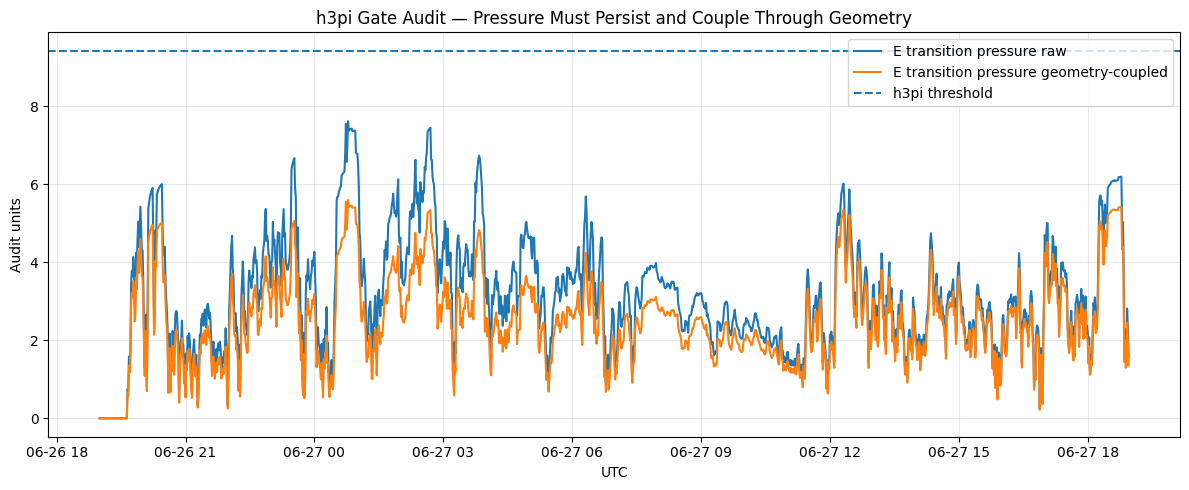

In [14]:
# --------------------- CHART 3: H3PI ENERGY GATE ---------------------

plt.figure(figsize=(12, 5))
plt.plot(ledger.index, ledger["E_transition_pressure_raw"], label="E transition pressure raw")
plt.plot(ledger.index, ledger["E_transition_pressure"], label="E transition pressure geometry-coupled")
plt.axhline(CONFIG["h3pi"], linestyle="--", label="h3pi threshold")
plt.title("h3pi Gate Audit — Pressure Must Persist and Couple Through Geometry")
plt.ylabel("Audit units")
plt.xlabel("UTC")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Solar Weather Adapter Diagnostic: Geometry Solution G

This chart is the adapter diagnostic. It shows how the Solar Weather Adapter constructs Earth geometry coupling `G_geometry` from physical scaffold terms.

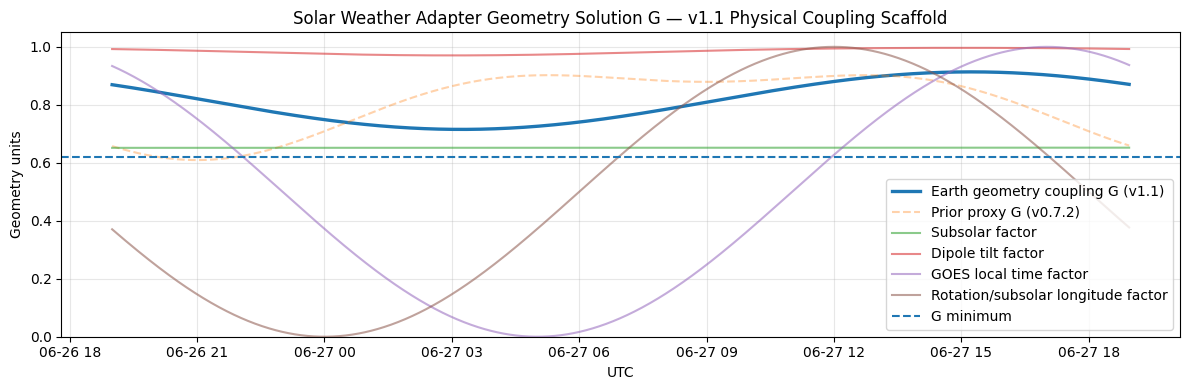

,subsolar_lat_deg,subsolar_lon_deg,dipole_tilt_deg_approx,goes_local_time_hr,G_geometry,geometry_subsolar_factor,geometry_dipole_tilt_factor,geometry_goes_local_time_factor
time_tag,,,,,,,,
2026-06-27 18:48:00+00:00,23.294930,-102.00,19.754776,13.786667,0.873677,0.652166,0.992771,0.946293
2026-06-27 18:49:00+00:00,23.294898,-102.25,19.778564,13.803333,0.873330,0.652167,0.992736,0.945305
2026-06-27 18:50:00+00:00,23.294867,-102.50,19.802420,13.820000,0.872983,0.652167,0.992700,0.944309
2026-06-27 18:51:00+00:00,23.294836,-102.75,19.826342,13.836667,0.872634,0.652168,0.992665,0.943304
2026-06-27 18:52:00+00:00,23.294805,-103.00,19.850330,13.853333,0.872284,0.652168,0.992629,0.942290
2026-06-27 18:53:00+00:00,23.294774,-103.25,19.874384,13.870000,0.871933,0.652168,0.992593,0.941269
2026-06-27 18:54:00+00:00,23.294743,-103.50,19.898502,13.886667,0.871581,0.652169,0.992557,0.940239
2026-06-27 18:55:00+00:00,23.294712,-103.75,19.922686,13.903333,0.871228,0.652169,0.992521,0.939200
2026-06-27 18:56:00+00:00,23.294681,-104.00,19.946933,13.920000,0.870874,0.652170,0.992484,0.938153


In [15]:
# --------------------- ADAPTER DIAGNOSTIC: GEOMETRY SOLUTION G ---------------------

plt.figure(figsize=(12, 4))
plt.plot(ledger.index, ledger["G_geometry"], linewidth=2.4, label="Earth geometry coupling G (v1.1)")
if "G_geometry_proxy_v072" in ledger.columns:
    plt.plot(ledger.index, ledger["G_geometry_proxy_v072"], alpha=0.35, linestyle="--", label="Prior proxy G (v0.7.2)")
for col, label in [
    ("geometry_subsolar_factor", "Subsolar factor"),
    ("geometry_dipole_tilt_factor", "Dipole tilt factor"),
    ("geometry_goes_local_time_factor", "GOES local time factor"),
    ("geometry_rotation_factor", "Rotation/subsolar longitude factor"),
]:
    if col in ledger.columns:
        plt.plot(ledger.index, ledger[col], alpha=0.55, label=label)
plt.axhline(CONFIG["geometry_gate_min"], linestyle="--", label="G minimum")
plt.ylim(0, 1.05)
plt.title("Solar Weather Adapter Geometry Solution G — v1.1 Physical Coupling Scaffold")
plt.ylabel("Geometry units")
plt.xlabel("UTC")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

geom_cols = [
    "subsolar_lat_deg", "subsolar_lon_deg", "dipole_tilt_deg_approx",
    "goes_local_time_hr", "G_geometry", "geometry_subsolar_factor",
    "geometry_dipole_tilt_factor", "geometry_goes_local_time_factor"
]
geom_cols = [c for c in geom_cols if c in ledger.columns]
display(ledger[geom_cols].tail(10))


## Audit: Raw Pressure Events

These rows identify places where the model wanted to exceed the no-transition cap or produced a needle-like raw pressure impulse. They are not automatically classified as storms. They are stress-test events for improving the boundary conditions.

In [16]:
# --------------------- RAW PRESSURE / SUPPRESSION AUDIT EVENTS ---------------------

audit_cols = [
    "perturbation_index",
    "transport_T",
    "Psi_persistence",
    "tau_persistent_windows",
    "candidate_survival_count",
    "G_geometry",
    "E_transition_pressure_raw",
    "E_transition_pressure",
    "raw_transition_pressure_kp",
    "fpdp_estimated_kp",
    "funt_estimated_kp",
    "h3pi_candidate",
    "condition_survives_x",
    "condition_geometry_ge_min",
    "h3pi_gate",
    "no_transition_cap_active",
    "persistence_suppression_audit",
    "geometry_suppression_audit",
    "needle_spike_audit",
    "fpdp_state",
    "funt_state",
]
if "observed_kp_validation_only" in ledger.columns:
    audit_cols.append("observed_kp_validation_only")

pressure_events = ledger.loc[
    ledger["no_transition_cap_active"]
    | ledger["needle_spike_audit"]
    | ledger["persistence_suppression_audit"]
    | ledger["geometry_suppression_audit"],
    audit_cols
].copy()

if pressure_events.empty:
    print("No raw-pressure, persistence-suppression, geometry-suppression, or needle audit events in this run.")
else:
    print(f"Audit events: {len(pressure_events)}")
    display(pressure_events.tail(25))


Audit events: 54


,perturbation_index,transport_T,Psi_persistence,tau_persistent_windows,candidate_survival_count,G_geometry,E_transition_pressure_raw,E_transition_pressure,raw_transition_pressure_kp,fpdp_estimated_kp,funt_estimated_kp,h3pi_candidate,condition_survives_x,condition_geometry_ge_min,h3pi_gate,no_transition_cap_active,persistence_suppression_audit,geometry_suppression_audit,needle_spike_audit,fpdp_state,funt_state,observed_kp_validation_only
time_tag,,,,,,,,,,,,,,,,,,,,,,
2026-06-27 02:21:00+00:00,0.756696,0.869883,0.950289,54,0,0.717784,6.626524,4.756412,3.159355,3.0,3.0,False,False,True,False,True,False,False,True,capped pressure / no transition,capped pressure / no transition,2.67
2026-06-27 02:34:00+00:00,0.691396,0.831503,1.014512,67,0,0.716651,6.443224,4.617543,3.101234,3.0,3.0,False,False,True,False,True,False,False,True,capped pressure / no transition,capped pressure / no transition,2.67
2026-06-27 02:35:00+00:00,0.662526,0.813957,1.047762,68,0,0.716577,6.361528,4.558525,3.076027,3.0,3.0,False,False,True,False,True,False,False,False,capped pressure / no transition,capped pressure / no transition,2.67
2026-06-27 02:36:00+00:00,0.737545,0.858804,1.093862,69,0,0.716505,6.670911,4.779741,3.186341,3.0,3.0,False,False,True,False,True,False,False,False,capped pressure / no transition,capped pressure / no transition,2.67
2026-06-27 02:37:00+00:00,0.773767,0.879640,1.140416,70,0,0.716435,6.832297,4.894895,3.246390,3.0,3.0,False,False,True,False,True,False,False,False,capped pressure / no transition,capped pressure / no transition,2.67
2026-06-27 02:38:00+00:00,0.911347,0.954645,1.210092,71,0,0.716366,7.340093,5.258195,3.428287,3.0,3.0,False,False,True,False,True,False,False,False,capped pressure / no transition,capped pressure / no transition,2.67
2026-06-27 02:39:00+00:00,0.911347,0.954645,1.267226,72,0,0.716300,7.377868,5.284766,3.448284,3.0,3.0,False,False,True,False,True,False,False,False,capped pressure / no transition,capped pressure / no transition,2.67
2026-06-27 02:40:00+00:00,0.911347,0.954645,1.314076,73,0,0.716235,7.407685,5.305645,3.464681,3.0,3.0,False,False,True,False,True,False,False,False,capped pressure / no transition,capped pressure / no transition,2.67
2026-06-27 02:41:00+00:00,0.911347,0.954645,1.352494,74,0,0.716173,7.431395,5.322161,3.478127,3.0,3.0,False,False,True,False,True,False,False,False,capped pressure / no transition,capped pressure / no transition,2.67


## Audit: Frozen Run Log

Each run can append the latest verdict to a CSV file. This makes performance monitoring cumulative. Do not edit the log retroactively. If model constants change, change the version label.

In [17]:
# --------------------- APPEND RUN LOG ---------------------

log_path = Path(CONFIG["prediction_log_csv"])
new_row = pd.DataFrame([verdict | metrics])

if log_path.exists():
    old = pd.read_csv(log_path)
    combined = pd.concat([old, new_row], ignore_index=True)
else:
    combined = new_row

combined.to_csv(log_path, index=False)
print(f"Saved/updated run log: {log_path.resolve()}")
display(combined.tail(10))


Saved/updated run log: /content/fpdp_solar_weather_adapter_v11_run_log.csv


,run_utc,version,synthetic_demo_mode,latest_time_utc,perturbation_detected,transport_response,persistence_threshold_met,survived_x_windows,geometry_gate_open,G_geometry,h3pi_candidate,h3pi_transition_confirmed,storm_regime,aftershock_watch,state,raw_transition_pressure_kp,fpdp_estimated_kp_final,no_transition_cap_active,observed_kp_validation_only,estimate_minus_actual,n_validation_points,mae,rmse,bias_est_minus_actual,correlation,max_abs_error
0,2026-06-27T18:59:36.473596+00:00,fpdp-solar-weather-adapter-v1.1-compatibility-...,False,2026-06-27T18:57:00+00:00,False,False,False,False,True,0.871,False,False,False,False,quiet / reference,1.461,1.461,False,1.33,0.131,1438,0.519893,0.69511,-0.016671,0.127041,2.0


## Standard Output Manifest

Every adapter should preserve the same output vocabulary:

```text
SITREP
History Plot
Audit
Run Log
Adapter Diagnostic
```

For this Solar Weather Adapter:

```text
SITREP      -> OPERATIONAL VERDICT
History Plot -> FPDP History Analysis and h³π/Ψ audit plots
Audit       -> AUDIT LEDGER + BOUNDARY AUDIT + raw pressure events
Run Log     -> fpdp_solar_weather_adapter_v11_run_log.csv
Diagnostic  -> Solar Weather Adapter Geometry Solution G
```


## Nature's Lesson

**Nature teaches that potential difference instills correction, but correction must survive persistence and geometry.**

Most disturbances are corrected through transport and relaxation. A new regime appears only when correction cannot dissipate persistent strain before the h³π threshold is crossed **and** Earth geometry admits coupling.

In FPDP language:

```text
Reference -> Potential Difference -> Flow -> Persistence -> Survival x -> Geometry Gate -> h³π Gate -> Transition or Relaxation -> Reference
```

If the model disagrees with Nature, the model is revised, not Nature.

## Notes for Future Versions

Recommended next improvements:

1. Replace approximations with more complete subsolar point, dipole tilt, GSM coordinates, and GOES local time calculations where possible.
2. Strengthen explicit OMNI / DSCOVR solar-wind lag correction.
3. Preserve current-state estimation separate from one-window aftershock watch.
4. Store every run with a hash of the configuration dictionary.
5. Add confusion matrix for storm/no-storm classification once enough runs exist.
6. Add event notebooks: quiet interval, false alarm, storm transition, suppressed transition, aftershock relaxation.
7. Keep the engine/adapters split: adapter changes should not silently alter core FPDP rules.

The goal is not to force every event into a storm prediction. The goal is to learn when Nature corrects the disturbance before transition and when Nature crosses into a new regime.

## Closing Note

This edition should be monitored without per-event tuning.

The scientific task is accumulation:

- quiet intervals,
- false alarms,
- storm transitions,
- suppressed transitions,
- aftershock relaxation.

**Nature corrects most disturbances before transition.  
The notebook's purpose is to learn when correction succeeds and when a new regime becomes allowable.**